Loaded: 345 rows | Countries: 15 | Years: 2000-2022


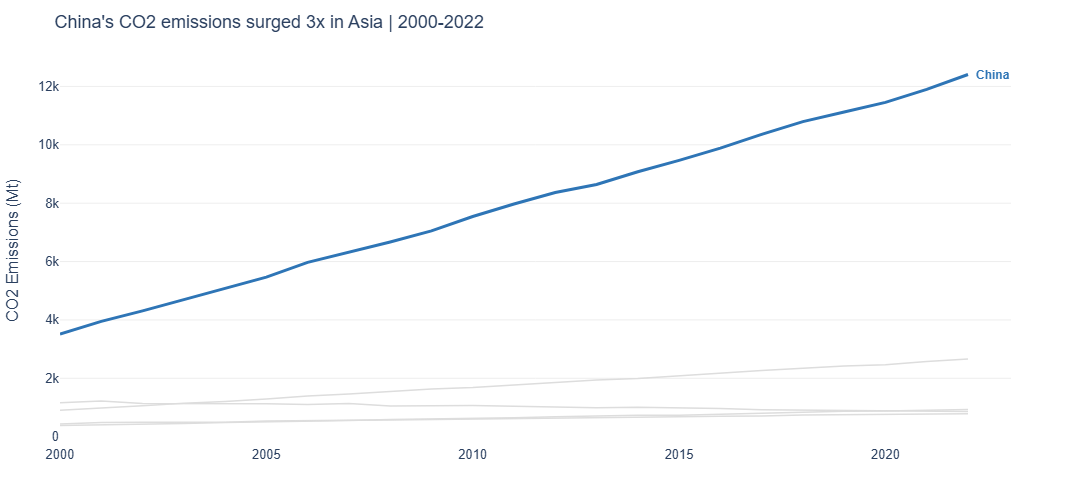

In [14]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")

asia_df = df[df['Region'] == 'Asia'].copy()
highlight_country = "China"

color_map = {
    country: "#2E75B6" if country == highlight_country else "#DDDDDD"
    for country in asia_df["Country"].unique()
}

fig1 = px.line(
    asia_df,
    x="Year",
    y="CO2_Mt",
    color="Country",
    color_discrete_map=color_map,
    labels={"CO2_Mt": "CO2 Emissions (Mt)", "Year": ""}
)

fig1.update_traces(
    line=dict(width=1.5),
    showlegend=False
)

fig1.update_traces(
    line=dict(width=3),
    selector=dict(name=highlight_country)
)

last_data = asia_df[
    (asia_df["Country"] == highlight_country) &
    (asia_df["Year"] == asia_df["Year"].max())
]
fig1.add_annotation(
    x=last_data["Year"].values[0],
    y=last_data["CO2_Mt"].values[0],
    text=f"<b>{highlight_country}</b>",
    showarrow=False,
    xanchor="left",
    xshift=6,
    font=dict(color="#2E75B6", size=12, family="Arial")
)

fig1.update_layout(

    title="China's CO2 emissions surged 3x in Asia | 2000-2022",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=13),
    yaxis=dict(gridcolor="#EEEEEE", title="CO2 Emissions (Mt)"),
    xaxis=dict(showgrid=False, title=""),
    margin=dict(l=60, r=80, t=55, b=40),
    height=500
)

fig1.show()


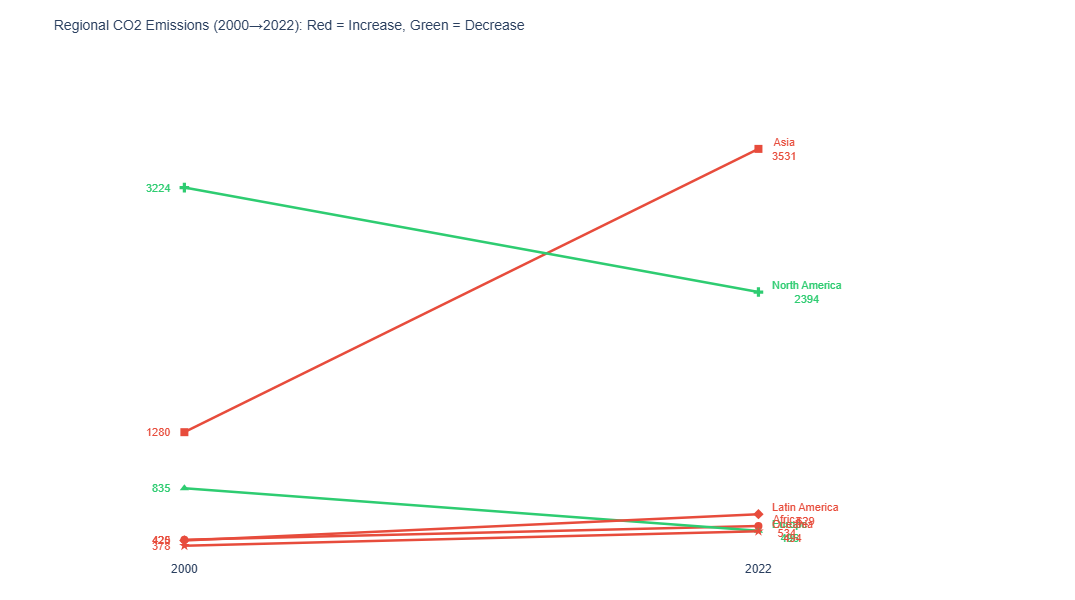

In [18]:
import pandas as pd
import plotly.graph_objects as go

regional_avg = df.groupby(["Region", "Year"])["CO2_Mt"].mean().reset_index()

slope_data = regional_avg[regional_avg["Year"].isin([2000, 2022])].sort_values(["Region", "Year"]).reset_index(drop=True)


slope_wide = slope_data.pivot(index="Region", columns="Year", values="CO2_Mt").reset_index()
slope_wide.columns = ["Region", "CO2_2000", "CO2_2022"]
slope_wide["Change"] = slope_wide["CO2_2022"] - slope_wide["CO2_2000"]


fig2 = go.Figure()

markers = ['circle', 'square', 'triangle-up', 'diamond', 'cross', 'star']
regions = slope_wide["Region"].tolist()

for i, region in enumerate(regions):
    row = slope_wide[slope_wide["Region"] == region].iloc[0]
    y0, y1 = row["CO2_2000"], row["CO2_2022"]

    line_color = "#E74C3C" if row["Change"] > 0 else "#2ECC71"
    
    
    fig2.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode="lines+markers",
        line=dict(color=line_color, width=2.5),
        marker=dict(color=line_color, size=8, symbol=markers[i % len(markers)]),
        name=region,
        showlegend=False
    ))
    
   
    fig2.add_annotation(
        x=2000,
        y=y0,
        text=f"{y0:.0f}",
        showarrow=False,
        xanchor="right",
        yanchor="middle",
        xshift=-12,  # 向左偏移，不压在点上
        font=dict(color=line_color, size=11, family="Arial")
    )
    
   
    fig2.add_annotation(
        x=2022,
        y=y1,
        text=f"{region}<br>{y1:.0f}",
        showarrow=False,
        xanchor="left",
        yanchor="middle",
        xshift=12,  
        font=dict(color=line_color, size=11, family="Arial")
    )


fig2.update_layout(
    title="Regional CO2 Emissions (2000→2022): Red = Increase, Green = Decrease",
    title_font=dict(family="Arial", size=14),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=12),
 
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=["2000", "2022"],
        showgrid=False,
        range=[1996, 2028]  
    ),

    yaxis=dict(
        showgrid=False,
        showticklabels=False,
        title="",
        range=[slope_wide[["CO2_2000", "CO2_2022"]].min().min() * 0.7, 
               slope_wide[["CO2_2000", "CO2_2022"]].max().max() * 1.2]
    ),

    margin=dict(l=80, r=160, t=60, b=40),
    height=600,
    width=1000
)

fig2.show()